# Complete Pairwise Tanimoto Fold-Distance Plots — Hi Tasks

This notebook generates figures from the fold-distance tables computed in:

`01_tanimoto_distance_tables_hi.ipynb`

No fingerprints, feature importances, model training or Tanimoto distances are recomputed here.

Loaded tables:

- `fold_distance_summary.csv`
- `fold_distance_nn_distributions.csv`
- `fold_distance_activity_detection_vs_random_bits_summary.csv`

The main plotted metric is the complete cross-fold pairwise Tanimoto distance.

For each model family, the analysis uses the selected configuration for each fold/protocol, ranks the corresponding ECFP4 features, restricts the fingerprint space to the top-k selected bits, and measures the fold-to-fold Tanimoto distance in that restricted space.

The main plots are model-wise and fold-wise:

- models: Decision Tree, Logistic Regression, Linear SVM;
- datasets: DRD2, HIV, Sol;
- fold pairs: F1 vs F2, F1 vs F3, F2 vs F3;
- selected feature spaces: OOD activity, random-shuffle activity, dataset detection;
- fingerprint space: ECFP4 2048 bits.

Restricted-space coverage is reported as a diagnostic for the projection from full ECFP4 to a top-k subset of bits.

In [1]:
import sys
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()

    current = start

    while current != current.parent:
        if all((current / d).exists() for d in ["data", "results"]):
            return current
        current = current.parent

    raise RuntimeError("Could not find project root.")


PROJECT_ROOT = find_project_root()

TASK = "hi"

DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS = DATASETS_MAIN

DATASET_LABELS = {
    "drd2": "DRD2",
    "hiv": "HIV",
    "sol": "Sol",
}

SUBSETS = ["F1", "F2", "F3"]
PAIRS = list(combinations(SUBSETS, 2))
PAIR_NAMES = [f"{a}_vs_{b}" for a, b in PAIRS]

PAIR_LABELS = {
    "F1_vs_F2": "F1 vs F2",
    "F1_vs_F3": "F1 vs F3",
    "F2_vs_F3": "F2 vs F3",
}

MODELS = ["DT", "LR", "SVM"]

MODEL_LABELS = {
    "DT": "Decision Tree",
    "LR": "Logistic Regression",
    "SVM": "Linear SVM",
}

K_VALUES_ALL = [10, 20, 50, 100, 150, 200, 250, 500]
K_VALUES_PLOT = [20, 50, 100, 150, 200, 250, 500]
N_RANDOM_BIT_REPEATS = 30

OUT_ROOT = PROJECT_ROOT / "results" / "results_fold_distance_tanimoto" / TASK
FIG_ROOT = OUT_ROOT / "figures" / "modelwise_tanimoto"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

DATASET_COLORS = {
    "drd2": "#4C78A8",
    "hiv": "#F58518",
    "sol": "#B279A2",
}

PAIR_COLORS = {
    "F1_vs_F2": "#4C78A8",
    "F1_vs_F3": "#F58518",
    "F2_vs_F3": "#54A24B",
}

SOURCE_COLORS = {
    "activity_ood": "#2563EB",
    "activity_random_shuffle": "#DC2626",
    "dataset_detection": "#7C3AED",
    "random_bits": "#95A5A6",
    "full_ecfp4": "#111827",
}

BIT_SOURCE_LABELS = {
    "full_ecfp4": "Full ECFP4",
    "activity_global": "Global activity",
    "activity_ood": "OOD activity",
    "activity_random_shuffle": "Random-shuffle activity",
    "dataset_detection": "Dataset detection",
    "random_bits": "Random bits",
}

print("Plot notebook setup completed.")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUT_ROOT: {OUT_ROOT}")
print(f"FIG_ROOT: {FIG_ROOT}")

Plot notebook setup completed.
PROJECT_ROOT: /home/f.capria/drug-discovery-lohi
OUT_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi
FIG_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto


In [3]:
dist_path = OUT_ROOT / "fold_distance_summary.csv"
hist_path = OUT_ROOT / "fold_distance_nn_distributions.csv"
summary_path = OUT_ROOT / "fold_distance_activity_detection_vs_random_bits_summary.csv"

if not dist_path.exists():
    raise FileNotFoundError(f"Missing distance table: {dist_path}")

if not hist_path.exists():
    raise FileNotFoundError(f"Missing NN histogram table: {hist_path}")

if not summary_path.exists():
    raise FileNotFoundError(f"Missing final summary table: {summary_path}")

dist_all = pd.read_csv(dist_path)
hist_all = pd.read_csv(hist_path)
final_summary = pd.read_csv(summary_path)

print("Loaded plotting tables.")
print(f"dist_all      : {dist_all.shape}")
print(f"hist_all      : {hist_all.shape}")
print(f"final_summary : {final_summary.shape}")

display(dist_all.head())
display(final_summary.head())

Loaded plotting tables.
dist_all      : (7371, 24)
hist_all      : (4672922, 14)
final_summary : (1107, 18)


,dataset,dataset_label,pair,outer_fold,space,k,model,bit_source,activity_protocol,activity_fold,...,nn_B_to_A_mean,wasserstein_nd,valid_molecule_fraction,n_valid_molecules,n_total_molecules,pairwise_distance,valid_pair_fraction,n_valid_pairs,n_total_pairs,pairwise_mode
0,drd2,DRD2,F1_vs_F2,1,full_ecfp4,2048,DT,full_ecfp4,NaN,NaN,...,0.699229,NaN,1.000000,2385,2385,0.852592,1.000000,1422054,1422054,complete
1,drd2,DRD2,F1_vs_F2,1,activity_global_top10,10,DT,activity_global,pooled,NaN,...,0.043879,NaN,0.927044,2211,2385,0.708013,0.994881,1414774,1422054,complete
2,drd2,DRD2,F1_vs_F2,1,activity_ood_top10,10,DT,activity_ood,ood,1.0,...,0.045716,NaN,0.906080,2161,2385,0.747359,0.991433,1409871,1422054,complete
3,drd2,DRD2,F1_vs_F2,1,activity_random_shuffle_top10,10,DT,activity_random_shuffle,random,1.0,...,0.018830,NaN,0.989099,2359,2385,0.546577,0.999882,1421886,1422054,complete
4,drd2,DRD2,F1_vs_F2,1,dataset_detection_top10,10,DT,dataset_detection,same_search_cv,1.0,...,0.219711,NaN,0.949266,2264,2385,0.743797,0.998169,1419450,1422054,complete


,dataset,dataset_label,model,pair,outer_fold,k,bit_source,activity_protocol,activity_fold,pairwise_distance_mean,pairwise_distance_std,valid_molecule_fraction_mean,valid_pair_fraction_mean,n_rows,full_pairwise_distance_mean,delta_minus_full_pairwise,random_bits_pairwise_distance_mean,delta_minus_random_bits_pairwise
0,drd2,DRD2,DT,F1_vs_F2,1,10,activity_global,pooled,NaN,0.708013,NaN,0.927044,0.994881,1,0.852592,-0.144579,0.942637,-0.234625
1,drd2,DRD2,DT,F1_vs_F2,1,10,activity_ood,ood,1.0,0.747359,NaN,0.906080,0.991433,1,0.852592,-0.105232,0.942637,-0.195278
2,drd2,DRD2,DT,F1_vs_F2,1,10,activity_random_shuffle,random,1.0,0.546577,NaN,0.989099,0.999882,1,0.852592,-0.306015,0.942637,-0.396060
3,drd2,DRD2,DT,F1_vs_F2,1,10,dataset_detection,same_search_cv,1.0,0.743797,NaN,0.949266,0.998169,1,0.852592,-0.108795,0.942637,-0.198841
4,drd2,DRD2,DT,F1_vs_F2,1,10,random_bits,NaN,NaN,0.942637,0.113057,0.231908,0.390877,30,0.852592,0.090046,0.942637,0.000000


In [ ]:
required_dist_cols = [
    "dataset",
    "dataset_label",
    "pair",
    "space",
    "k",
    "model",
    "bit_source",
    "activity_protocol",
    "pairwise_distance",
    "valid_molecule_fraction",
    "valid_pair_fraction",
]

missing = [c for c in required_dist_cols if c not in dist_all.columns]
if missing:
    raise ValueError(f"Missing required columns in dist_all: {missing}")

if dist_all["pairwise_distance"].notna().sum() == 0:
    raise RuntimeError("All pairwise_distance values are NaN.")

unexpected_datasets = set(dist_all["dataset"].unique()) - set(DATASETS)
if unexpected_datasets:
    raise ValueError(f"Unexpected datasets in dist_all: {unexpected_datasets}")

assert "kdr" not in set(
    dist_all["dataset"].astype(str).str.lower()
), "KDR found in Tanimoto plot table."

expected_sources = {
    "full_ecfp4",
    "activity_global",
    "activity_ood",
    "activity_random_shuffle",
    "dataset_detection",
    "random_bits",
}

observed_sources = set(dist_all["bit_source"].dropna().unique())
missing_sources = expected_sources - observed_sources

if missing_sources:
    raise ValueError(
        "The plotting notebook is still reading old Tanimoto tables. "
        f"Missing bit sources: {missing_sources}. "
        "Re-run the updated table notebook first."
    )

missing_models = set(MODELS) - set(dist_all["model"].dropna().unique())
if missing_models:
    raise ValueError(f"Missing models in dist_all: {missing_models}")

observed_k = set(
    dist_all.loc[dist_all["bit_source"] != "full_ecfp4", "k"]
    .dropna()
    .astype(int)
    .unique()
)

expected_k = set(K_VALUES_ALL)

if observed_k != expected_k:
    raise ValueError(
        f"Unexpected k values. Observed={sorted(observed_k)}, "
        f"expected={sorted(expected_k)}"
    )

expected_rows = (
    len(DATASETS)
    * len(MODELS)
    * len(PAIR_NAMES)
    * (1 + len(K_VALUES_ALL) * (4 + N_RANDOM_BIT_REPEATS))
)

if len(dist_all) != expected_rows:
    raise ValueError(
        f"Unexpected dist_all rows: got {len(dist_all)}, expected {expected_rows}. "
        "This usually means the table notebook has not been regenerated."
    )

print("Sanity checks passed.")
print(
    f"Finite pairwise_distance: "
    f"{dist_all['pairwise_distance'].notna().sum()}/{len(dist_all)}"
)

Sanity checks passed.
Finite pairwise_distance: 7371/7371


In [5]:
def set_plot_style():
    mpl.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.3,
            "ytick.labelsize": 8.3,
            "legend.fontsize": 8.3,
            "figure.dpi": 150,
            "savefig.dpi": 600,
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )


def model_label(model: str) -> str:
    return MODEL_LABELS.get(model, model)


def source_label(src: str) -> str:
    return BIT_SOURCE_LABELS.get(src, src)


def pair_label(pair: str) -> str:
    return PAIR_LABELS.get(pair, pair)


def save_fig(fig, name: str):
    fname = FIG_ROOT / name
    fig.savefig(f"{fname}.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    print(f"Saved: {fname}.png")
    print(f"Saved: {fname}.pdf")


set_plot_style()

print("Plot style configured.")

Plot style configured.


In [ ]:
def get_distance_by_k(
    dist_all: pd.DataFrame,
    dataset: str,
    model: str,
    pair: str,
    bit_source: str,
    metric: str = "pairwise_distance",
) -> pd.DataFrame:
    sub = dist_all[
        (dist_all["dataset"] == dataset)
        & (dist_all["model"] == model)
        & (dist_all["pair"] == pair)
        & (dist_all["bit_source"] == bit_source)
        & (dist_all["k"].isin(K_VALUES_PLOT))
    ].copy()

    if sub.empty:
        return pd.DataFrame(columns=["k", metric])

    return sub.groupby("k", as_index=False)[metric].mean().sort_values("k")


def get_full_ecfp4_reference(
    dist_all: pd.DataFrame,
    dataset: str,
    model: str,
    pair: str,
) -> float:
    sub = dist_all[
        (dist_all["dataset"] == dataset)
        & (dist_all["model"] == model)
        & (dist_all["pair"] == pair)
        & (dist_all["bit_source"] == "full_ecfp4")
    ]

    if sub.empty:
        return np.nan

    return float(sub["pairwise_distance"].mean())

## Activity-restricted fold distance

This figure compares fold-to-fold complete pairwise Tanimoto distances after projecting full ECFP4 fingerprints to top-k activity-relevant bits.

Each figure fixes one model family.

Rows are datasets. Columns are activity-selection protocols. Lines are fold pairs.

The dotted horizontal lines show the corresponding full ECFP4 distance for each fold pair.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_dt.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_dt.pdf


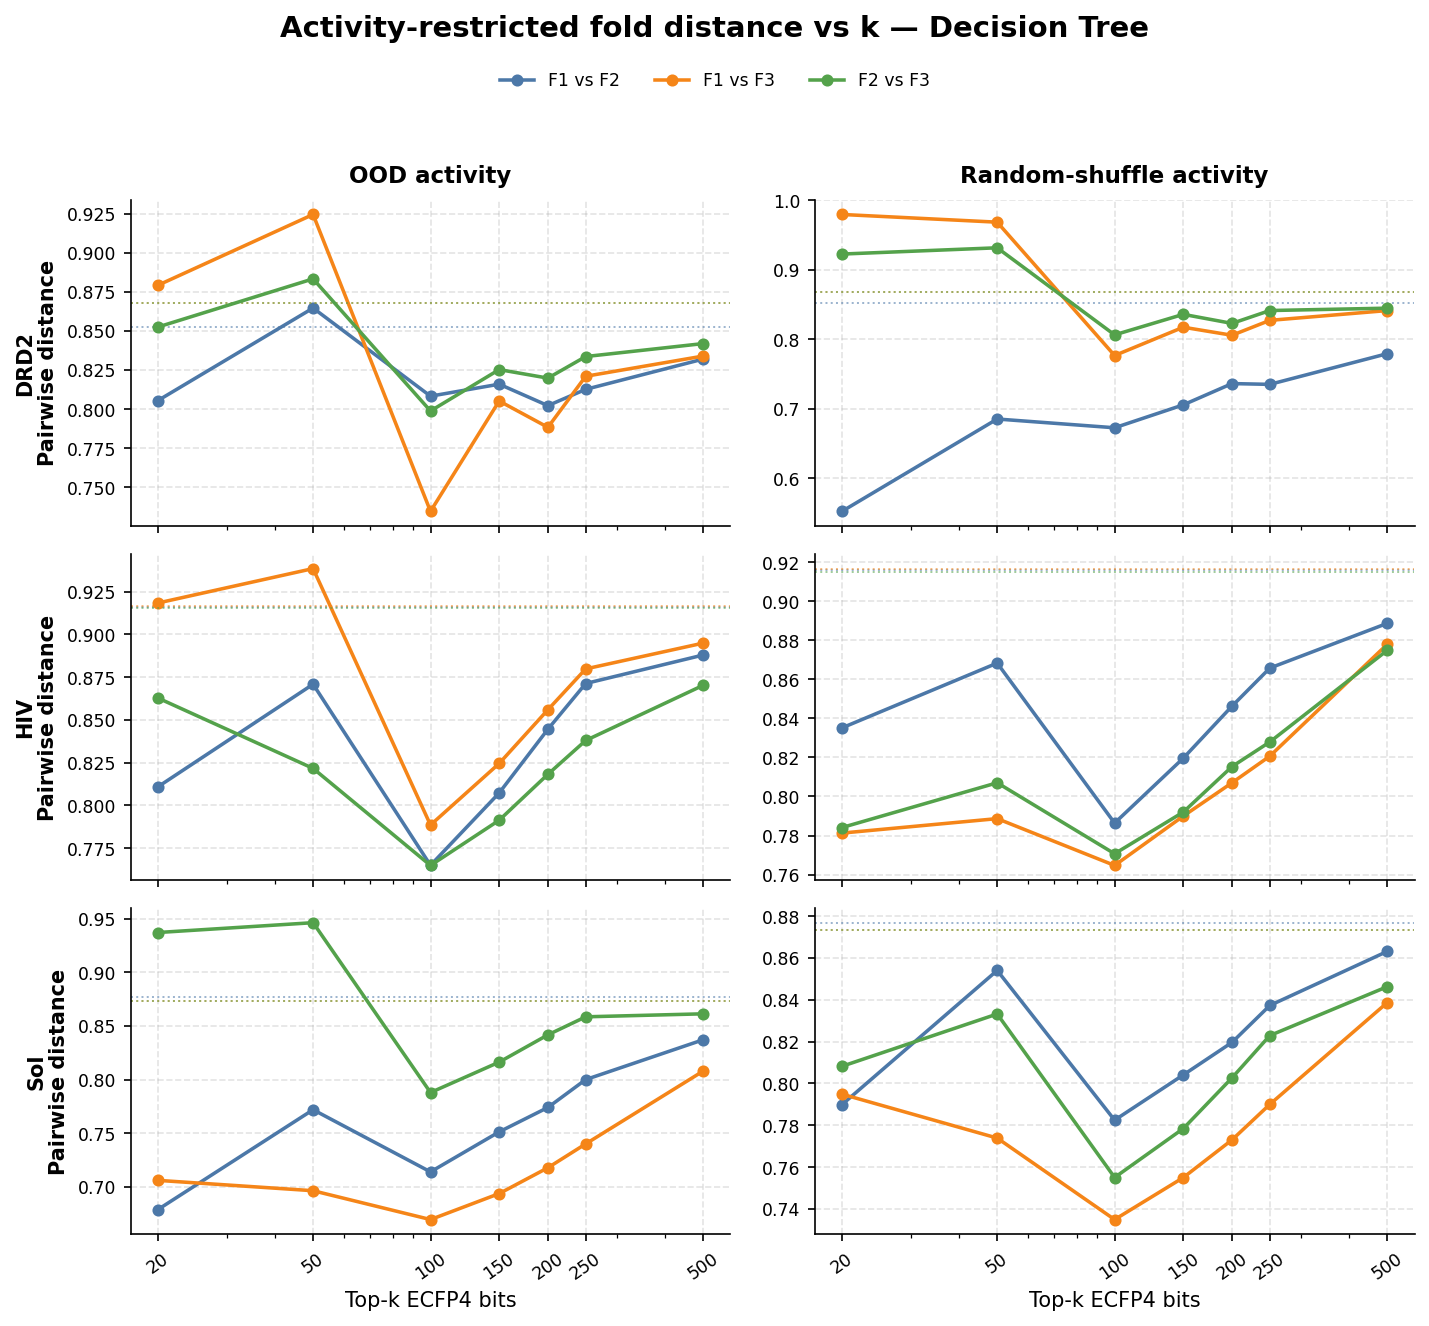

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_lr.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_lr.pdf


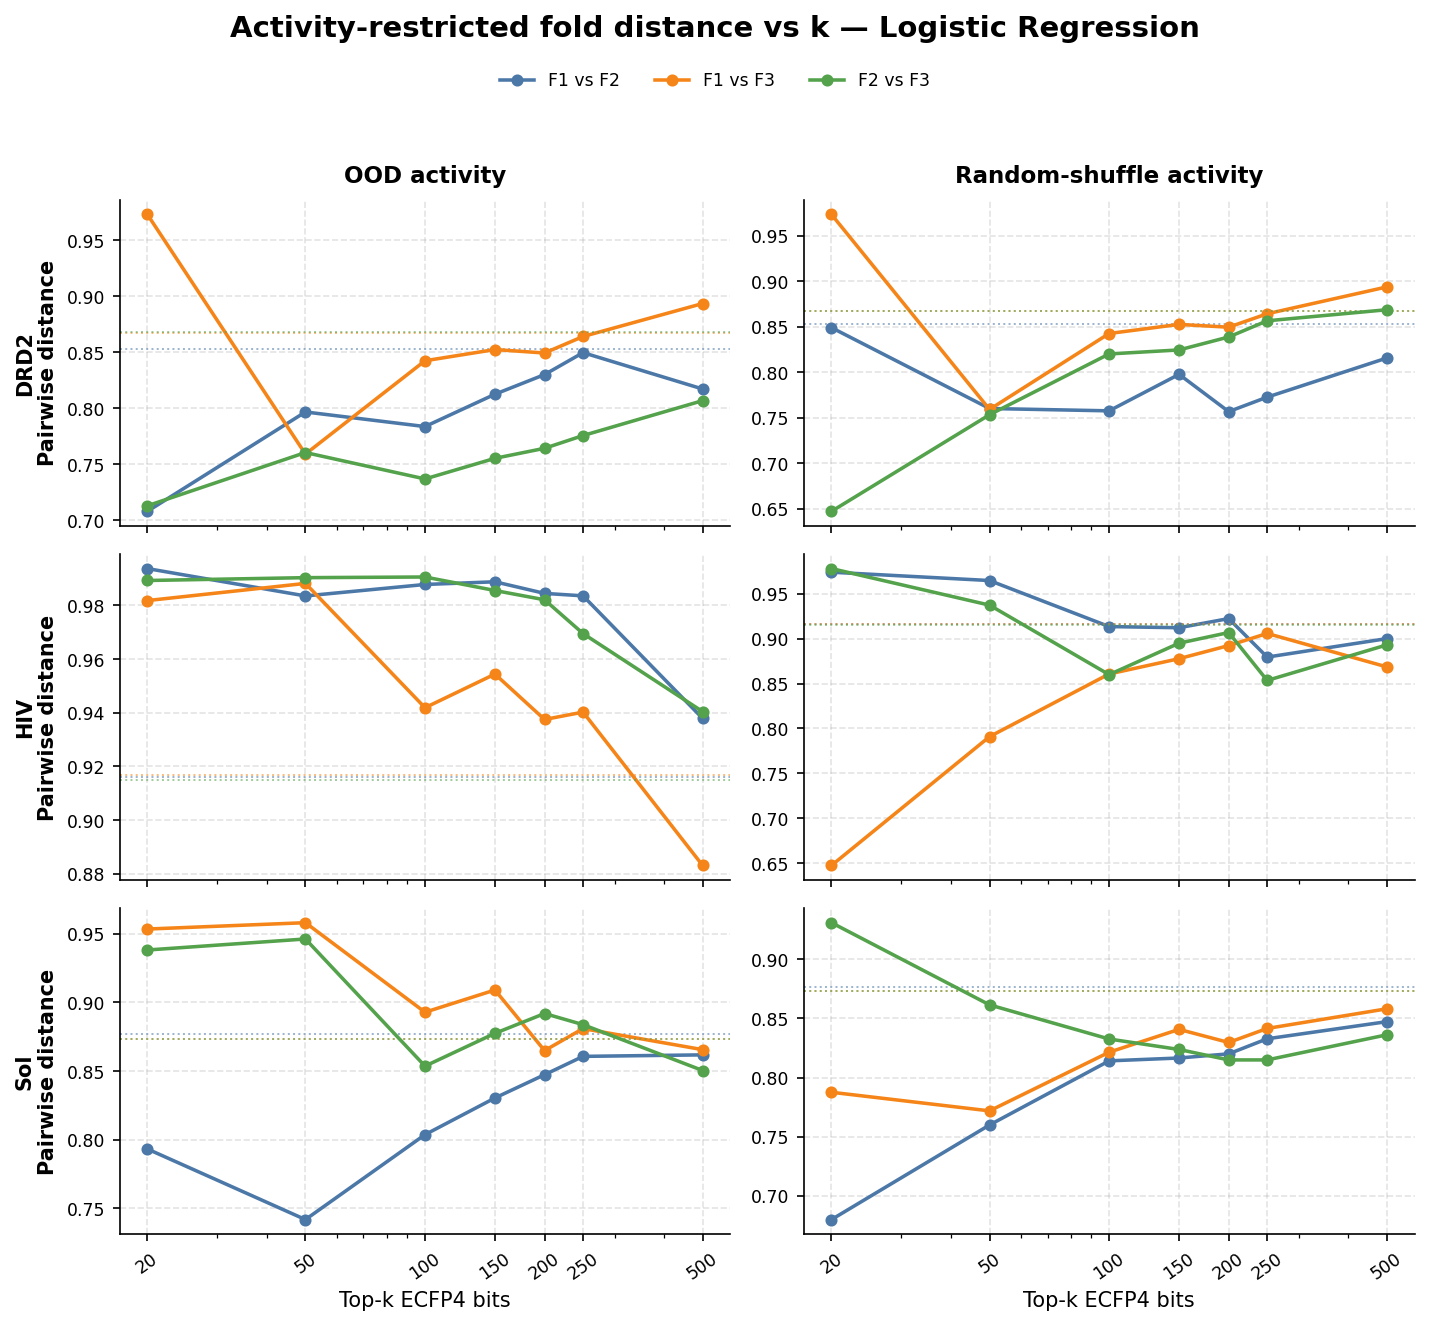

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_svm.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/activity_restricted_fold_distance_svm.pdf


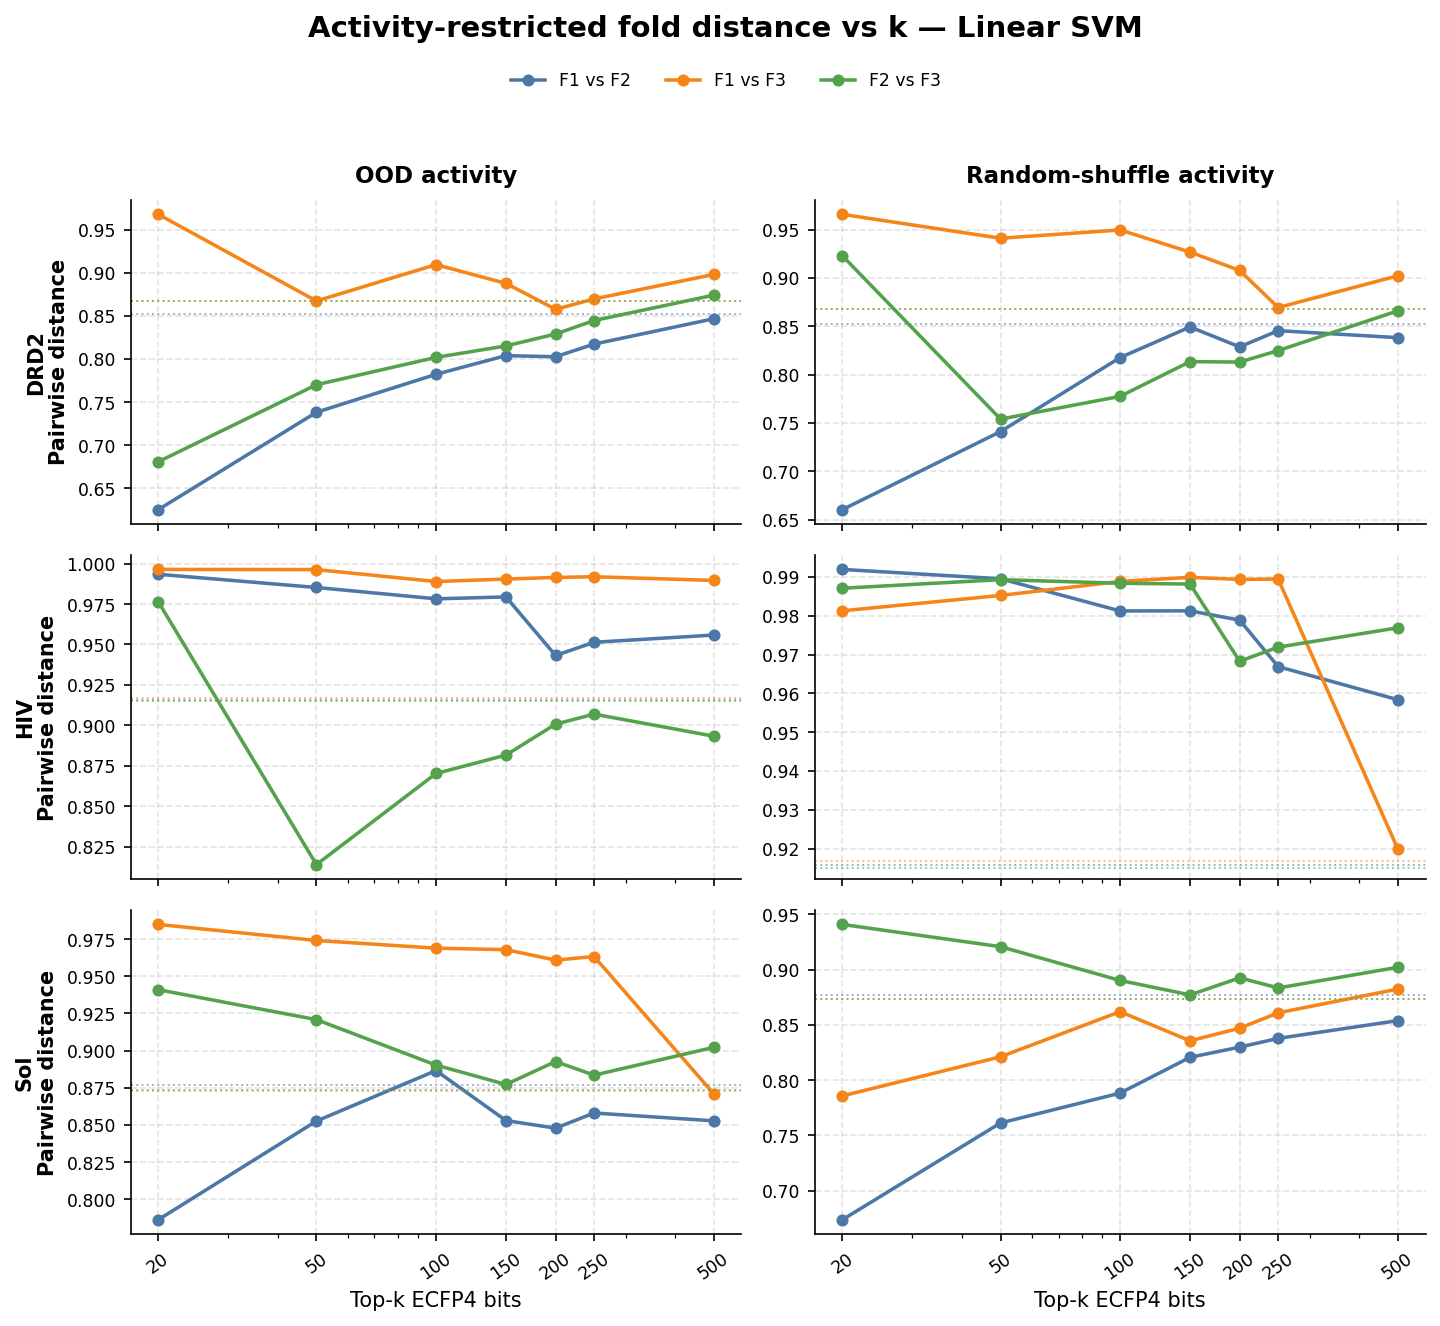

In [8]:
def fig_activity_restricted_distance_by_model(
    dist_all: pd.DataFrame,
    model: str,
):
    set_plot_style()

    sources = [
        ("activity_ood", "OOD activity"),
        ("activity_random_shuffle", "Random-shuffle activity"),
    ]

    n_rows = len(DATASETS)
    n_cols = len(sources)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(9.6, 8.4),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    for i, ds in enumerate(DATASETS):
        for j, (src, src_title) in enumerate(sources):
            ax = axes[i, j]

            for pair in PAIR_NAMES:
                sub = get_distance_by_k(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                    bit_source=src,
                    metric="pairwise_distance",
                )

                if sub.empty:
                    continue

                ax.plot(
                    sub["k"],
                    sub["pairwise_distance"],
                    marker="o",
                    markersize=4.8,
                    lw=1.7,
                    color=PAIR_COLORS.get(pair, "C0"),
                    label=pair_label(pair),
                )

                full_ref = get_full_ecfp4_reference(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                )

                if np.isfinite(full_ref):
                    ax.axhline(
                        full_ref,
                        ls=":",
                        lw=0.95,
                        color=PAIR_COLORS.get(pair, "C0"),
                        alpha=0.55,
                    )

            ax.set_xscale("log")
            ax.set_xticks(K_VALUES_PLOT)
            ax.set_xticklabels([str(k) for k in K_VALUES_PLOT], rotation=35)
            ax.grid(ls="--", alpha=0.35)

            if i == 0:
                ax.set_title(src_title, fontweight="bold", pad=8)

            if j == 0:
                ax.set_ylabel(
                    f"{DATASET_LABELS.get(ds, ds)}\nPairwise distance",
                    fontweight="bold",
                )

            if i == n_rows - 1:
                ax.set_xlabel("Top-k ECFP4 bits")

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.012),
    )

    fig.suptitle(
        f"Activity-restricted fold distance vs k — {model_label(model)}",
        y=1.045,
        fontweight="bold",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.98])

    save_fig(
        fig,
        f"activity_restricted_fold_distance_{model.lower()}",
    )

    plt.show()
    plt.close(fig)


for model in MODELS:
    fig_activity_restricted_distance_by_model(dist_all, model)

## Dataset-detection restricted fold distance

This figure measures fold-to-fold complete pairwise Tanimoto distances after projecting full ECFP4 fingerprints to top-k fold-discriminating bits.

Rows are datasets. Columns are model families. Lines are fold pairs.

The dotted horizontal lines show the corresponding full ECFP4 distance for each fold pair.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/dataset_detection_restricted_fold_distance_grid.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/dataset_detection_restricted_fold_distance_grid.pdf


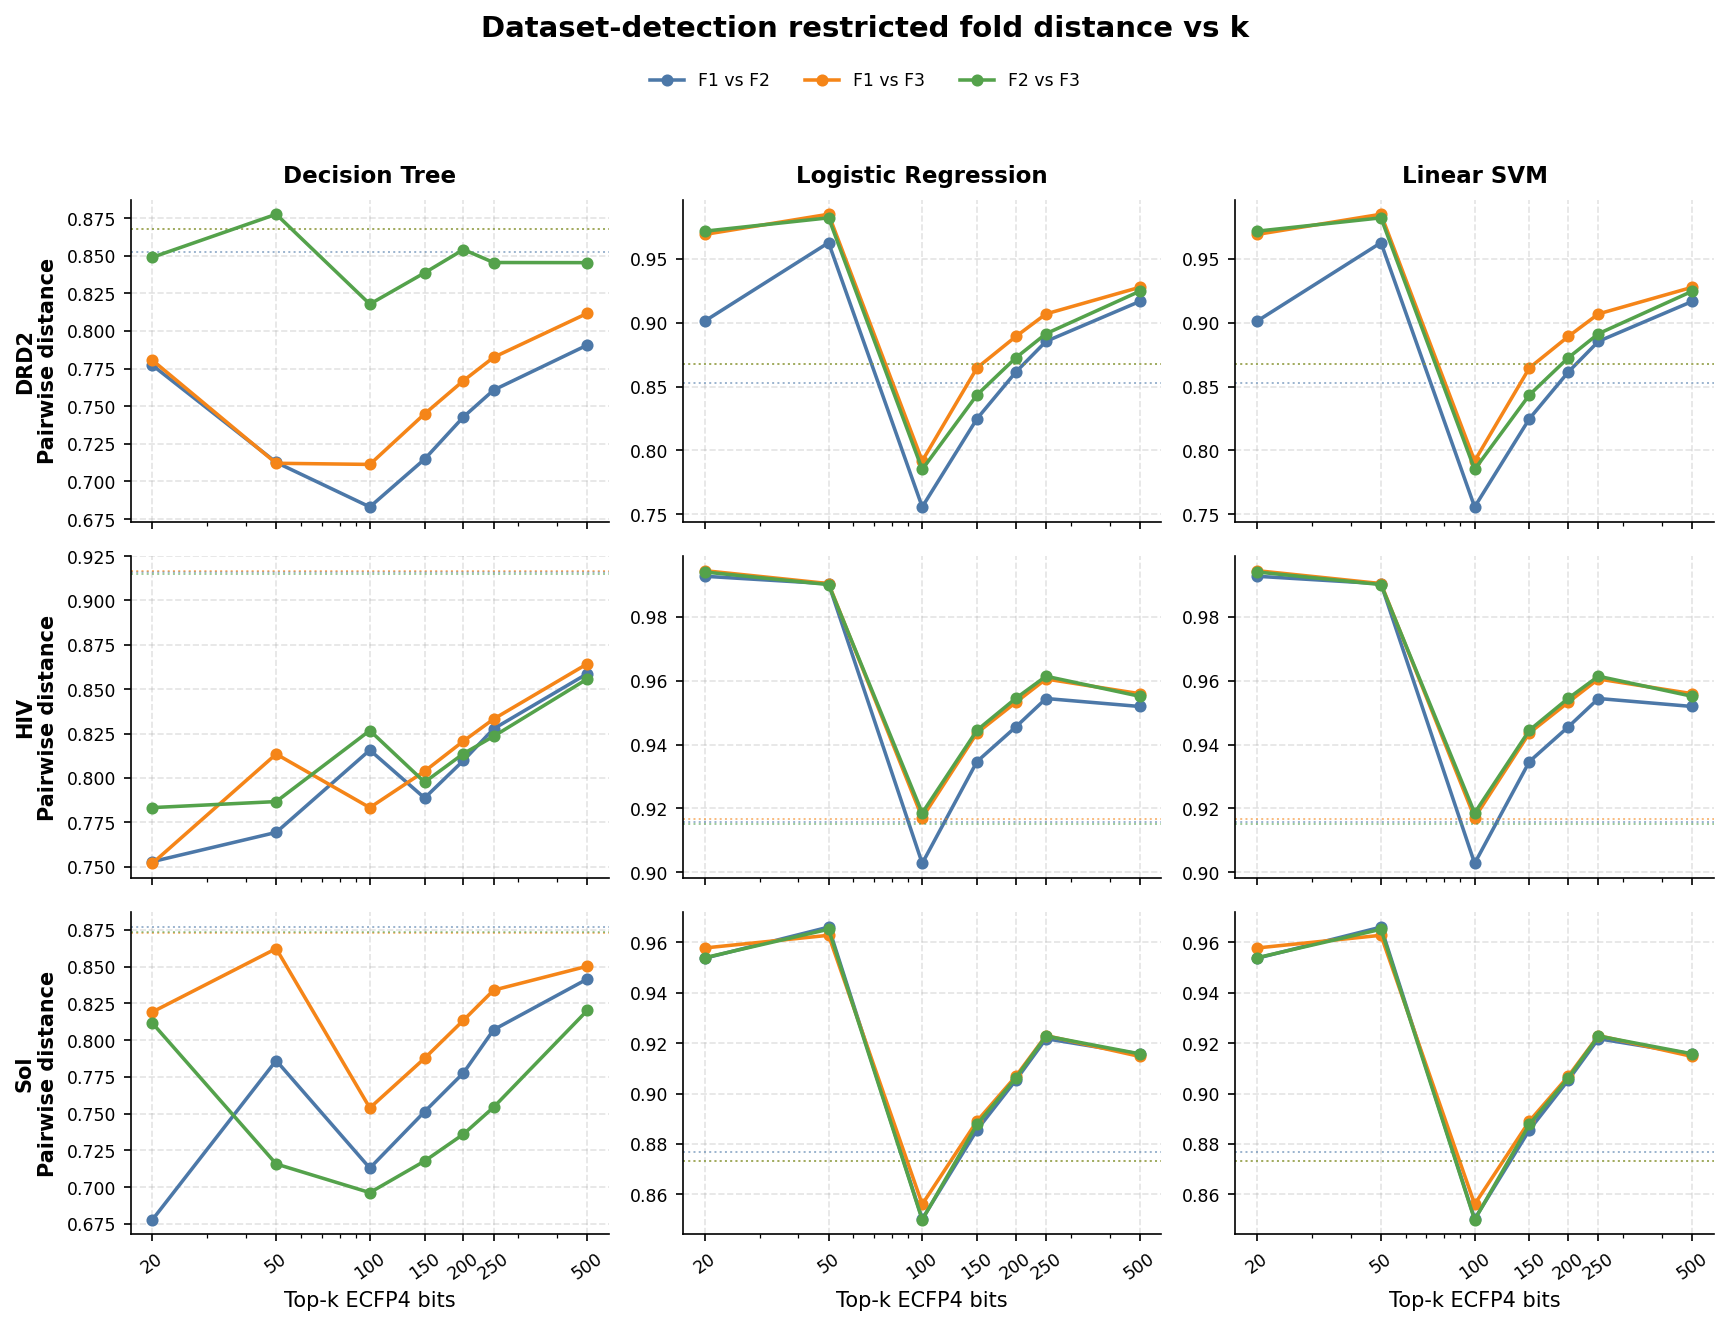

In [9]:
def fig_dataset_detection_restricted_distance_grid(
    dist_all: pd.DataFrame,
):
    set_plot_style()

    n_rows = len(DATASETS)
    n_cols = len(MODELS)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(11.6, 8.4),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    for i, ds in enumerate(DATASETS):
        for j, model in enumerate(MODELS):
            ax = axes[i, j]

            for pair in PAIR_NAMES:
                sub = get_distance_by_k(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                    bit_source="dataset_detection",
                    metric="pairwise_distance",
                )

                if sub.empty:
                    continue

                ax.plot(
                    sub["k"],
                    sub["pairwise_distance"],
                    marker="o",
                    markersize=4.8,
                    lw=1.7,
                    color=PAIR_COLORS.get(pair, "C0"),
                    label=pair_label(pair),
                )

                full_ref = get_full_ecfp4_reference(
                    dist_all=dist_all,
                    dataset=ds,
                    model=model,
                    pair=pair,
                )

                if np.isfinite(full_ref):
                    ax.axhline(
                        full_ref,
                        ls=":",
                        lw=0.95,
                        color=PAIR_COLORS.get(pair, "C0"),
                        alpha=0.55,
                    )

            ax.set_xscale("log")
            ax.set_xticks(K_VALUES_PLOT)
            ax.set_xticklabels([str(k) for k in K_VALUES_PLOT], rotation=35)
            ax.grid(ls="--", alpha=0.35)

            if i == 0:
                ax.set_title(model_label(model), fontweight="bold", pad=8)

            if j == 0:
                ax.set_ylabel(
                    f"{DATASET_LABELS.get(ds, ds)}\nPairwise distance",
                    fontweight="bold",
                )

            if i == n_rows - 1:
                ax.set_xlabel("Top-k ECFP4 bits")

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.012),
    )

    fig.suptitle(
        "Dataset-detection restricted fold distance vs k",
        y=1.045,
        fontweight="bold",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.98])

    save_fig(
        fig,
        "dataset_detection_restricted_fold_distance_grid",
    )

    plt.show()
    plt.close(fig)


fig_dataset_detection_restricted_distance_grid(dist_all)

## Restricted-space coverage

This diagnostic checks the projection from full ECFP4 fingerprints to a top-k subset of selected bits.

When the fingerprint space is restricted, some molecules may become all-zero in the selected subspace. If this happens frequently, restricted-space Tanimoto distances can become unstable or hard to interpret.

The plot reports the fraction of molecules that remain valid after the projection.

The random-bit baseline shows how much coverage is expected from an arbitrary top-k subset of ECFP4 bits.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/projection_coverage_full_ecfp4_to_topk_subset.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/projection_coverage_full_ecfp4_to_topk_subset.pdf


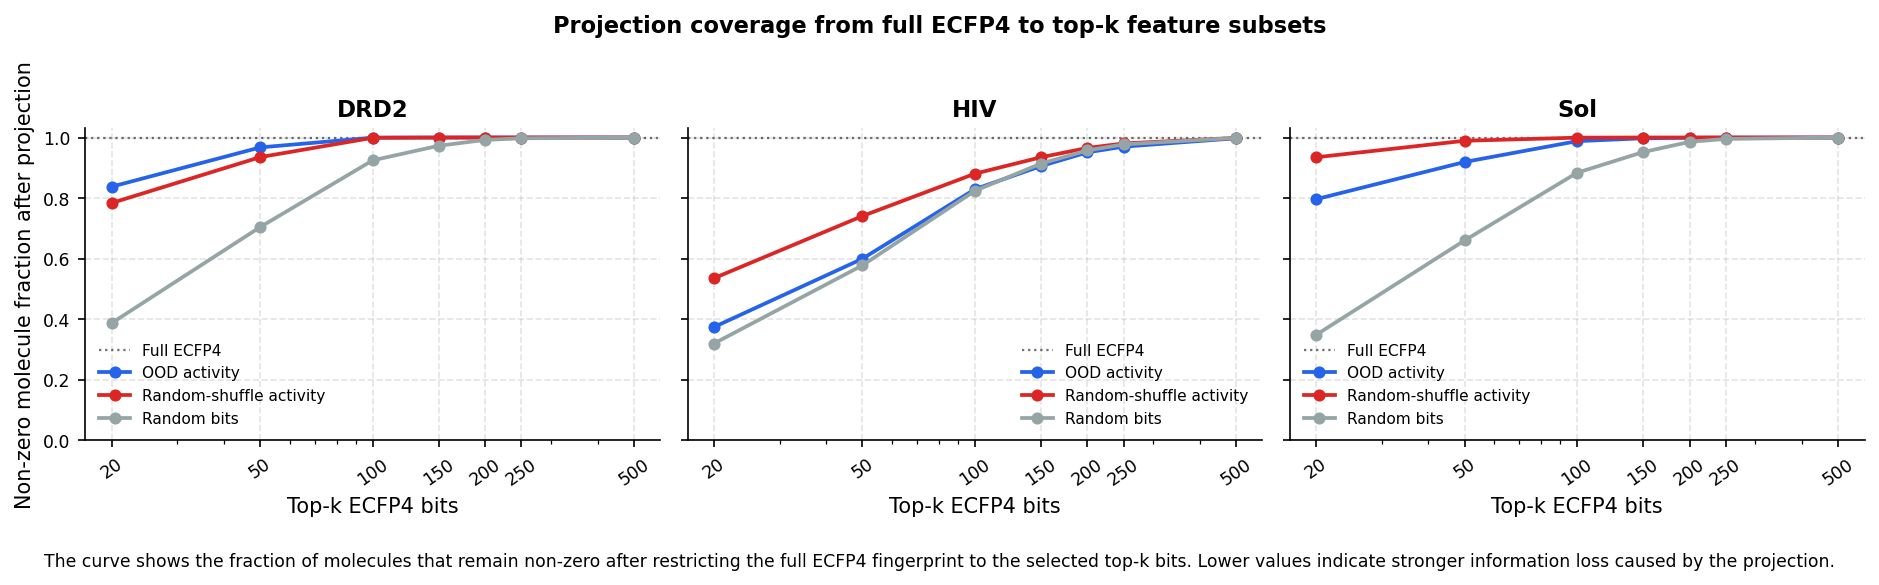

In [10]:
def fig_valid_fraction_vs_k(dist_all: pd.DataFrame):
    set_plot_style()

    projection_sources = [
        ("activity_ood", "OOD activity"),
        ("activity_random_shuffle", "Random-shuffle activity"),
        ("random_bits", "Random bits"),
    ]

    source_colors = {
        "activity_ood": "#2563EB",
        "activity_random_shuffle": "#DC2626",
        "random_bits": "#95A5A6",
    }

    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]

    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(4.2 * len(datasets), 3.35),
        sharey=True,
        squeeze=False,
    )

    for ax, ds in zip(axes[0], datasets):
        ax.axhline(
            1.0,
            ls=":",
            lw=1.1,
            color="black",
            alpha=0.55,
            label="Full ECFP4",
        )

        for src, label in projection_sources:
            sub = dist_all[
                (dist_all["dataset"] == ds)
                & (dist_all["bit_source"] == src)
                & (dist_all["k"].isin(K_VALUES_PLOT))
            ].copy()

            if sub.empty:
                continue

            agg = (
                sub.groupby("k", as_index=False)["valid_molecule_fraction"]
                .mean()
                .sort_values("k")
            )

            ax.plot(
                agg["k"],
                agg["valid_molecule_fraction"],
                marker="o",
                markersize=4.8,
                lw=1.8,
                color=source_colors[src],
                label=label,
            )

        ax.set_xscale("log")
        ax.set_xticks(K_VALUES_PLOT)
        ax.set_xticklabels([str(k) for k in K_VALUES_PLOT], rotation=35)
        ax.set_ylim(0, 1.03)
        ax.set_xlabel("Top-k ECFP4 bits")
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.grid(ls="--", alpha=0.35)
        ax.legend(frameon=False, fontsize=7.4)

    axes[0, 0].set_ylabel("Non-zero molecule fraction after projection")

    fig.suptitle(
        "Projection coverage from full ECFP4 to top-k feature subsets",
        fontweight="bold",
        y=1.04,
    )

    fig.text(
        0.5,
        -0.03,
        "The curve shows the fraction of molecules that remain non-zero after restricting the full ECFP4 fingerprint "
        "to the selected top-k bits. Lower values indicate stronger information loss caused by the projection.",
        ha="center",
        va="top",
        fontsize=8.3,
    )

    fig.tight_layout()

    save_fig(fig, "projection_coverage_full_ecfp4_to_topk_subset")

    plt.show()
    plt.close(fig)


fig_valid_fraction_vs_k(dist_all)

## Diagnostic heatmap: full ECFP4 vs activity-restricted space

This diagnostic compares fold-to-fold complete pairwise Tanimoto distances computed in the full ECFP4 space against distances computed after restricting ECFP4 to top-k activity-relevant bits.

The restricted activity space can be selected either from OOD activity validation or from random-shuffle activity validation.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/diagnostic_distance_heatmap_full_vs_ood_activity_top100.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/diagnostic_distance_heatmap_full_vs_ood_activity_top100.pdf


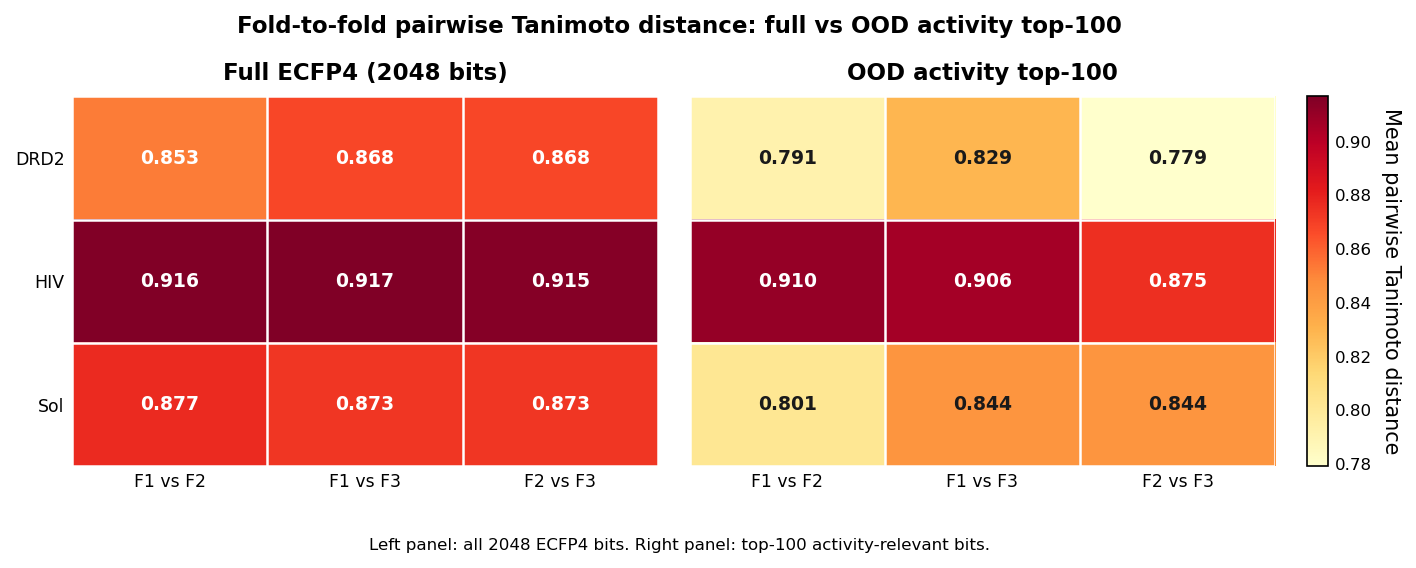

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/diagnostic_distance_heatmap_full_vs_random_activity_top100.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/diagnostic_distance_heatmap_full_vs_random_activity_top100.pdf


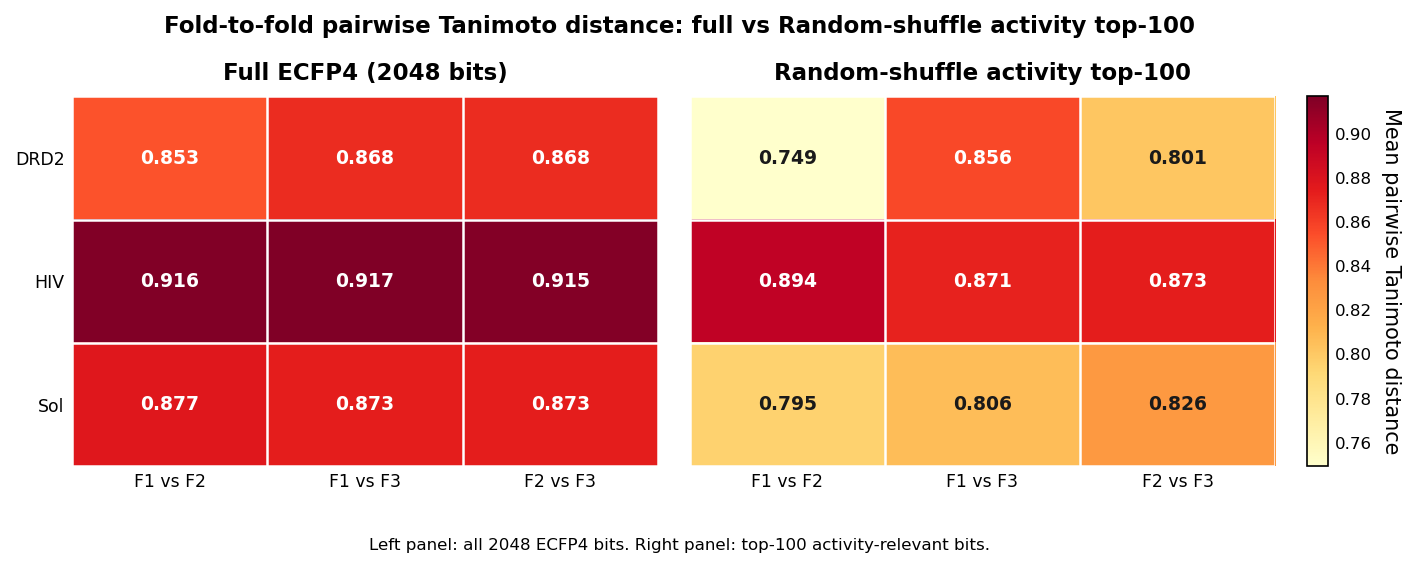

In [ ]:
def fig_distance_heatmap(
    dist_all: pd.DataFrame,
    k_show: int = 100,
    source_prefix: str = "ood",
):
    set_plot_style()

    src_map = {
        "ood": "activity_ood",
        "random": "activity_random_shuffle",
    }

    if source_prefix not in src_map:
        raise ValueError(
            f"Unknown source_prefix={source_prefix}. "
            f"Expected one of {list(src_map.keys())}."
        )

    bit_src = src_map[source_prefix]
    pair_cols = PAIR_NAMES

    full_sub = dist_all[dist_all["bit_source"] == "full_ecfp4"]

    rest_sub = dist_all[(dist_all["bit_source"] == bit_src) & (dist_all["k"] == k_show)]

    mat_full = (
        full_sub.groupby(["dataset", "pair"], as_index=False)["pairwise_distance"]
        .mean()
        .pivot(index="dataset", columns="pair", values="pairwise_distance")
        .reindex(DATASETS)[pair_cols]
    )

    mat_rest = (
        rest_sub.groupby(["dataset", "pair"], as_index=False)["pairwise_distance"]
        .mean()
        .pivot(index="dataset", columns="pair", values="pairwise_distance")
        .reindex(DATASETS)[pair_cols]
    )

    all_vals = np.concatenate(
        [
            mat_full.values[np.isfinite(mat_full.values)],
            mat_rest.values[np.isfinite(mat_rest.values)],
        ]
    )

    vmin = float(all_vals.min()) if len(all_vals) else 0.0
    vmax = float(all_vals.max()) if len(all_vals) else 1.0

    cmap = mpl.colormaps["YlOrRd"].copy()
    cmap.set_bad(color="lightgray")

    fig = plt.figure(figsize=(10.8, 3.2))

    gs = fig.add_gridspec(
        nrows=1,
        ncols=3,
        width_ratios=[1, 1, 0.035],
        wspace=0.08,
    )

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
    ]

    cax = fig.add_subplot(gs[0, 2])

    titles = {
        0: "Full ECFP4 (2048 bits)",
        1: f"{source_label(bit_src)} top-{k_show}",
    }

    mats = [mat_full, mat_rest]
    last_im = None

    for idx, (ax, mat) in enumerate(zip(axes, mats)):
        data = np.ma.masked_invalid(mat.values.astype(float))

        last_im = ax.imshow(
            data,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_title(titles[idx], fontweight="bold", pad=8)

        ax.set_xticks(range(mat.shape[1]))
        ax.set_xticklabels(
            [PAIR_LABELS.get(c, c) for c in mat.columns],
            rotation=0,
            ha="center",
        )

        ax.set_yticks(range(mat.shape[0]))
        ax.set_yticklabels([DATASET_LABELS.get(d, d) for d in mat.index])

        ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)

        ax.grid(which="minor", color="white", linewidth=1.2)

        ax.tick_params(which="minor", bottom=False, left=False)
        ax.tick_params(axis="both", length=0)

        for spine in ax.spines.values():
            spine.set_visible(False)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.iloc[i, j]

                if pd.notna(v):
                    mid = (vmin + vmax) / 2
                    text_color = "white" if v >= mid else "0.10"

                    ax.text(
                        j,
                        i,
                        f"{v:.3f}",
                        ha="center",
                        va="center",
                        fontsize=9,
                        fontweight="bold",
                        color=text_color,
                    )

    axes[1].tick_params(labelleft=False)

    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label(
        "Mean pairwise Tanimoto distance",
        rotation=270,
        labelpad=14,
    )
    cbar.ax.tick_params(length=0, labelsize=8)

    fig.suptitle(
        f"Fold-to-fold pairwise Tanimoto distance: "
        f"full vs {source_label(bit_src)} top-{k_show}",
        fontweight="bold",
        y=1.05,
        fontsize=11,
    )

    fig.text(
        0.5,
        -0.04,
        f"Left panel: all 2048 ECFP4 bits. "
        f"Right panel: top-{k_show} activity-relevant bits.",
        ha="center",
        va="top",
        fontsize=8,
    )

    save_fig(
        fig,
        f"diagnostic_distance_heatmap_full_vs_{source_prefix}_activity_top{k_show}",
    )

    plt.show()
    plt.close(fig)


fig_distance_heatmap(dist_all, k_show=100, source_prefix="ood")
fig_distance_heatmap(dist_all, k_show=100, source_prefix="random")

## Diagnostic heatmap: selected top-k spaces vs random-bit baseline

This diagnostic compares selected top-k spaces against random top-k ECFP4 bits.

It checks whether restricted-space distances are driven by meaningful feature selection or simply by reducing the dimensionality of the fingerprint.

Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/diagnostic_selected_vs_random_bits_heatmap_delta.png
Saved: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto/diagnostic_selected_vs_random_bits_heatmap_delta.pdf


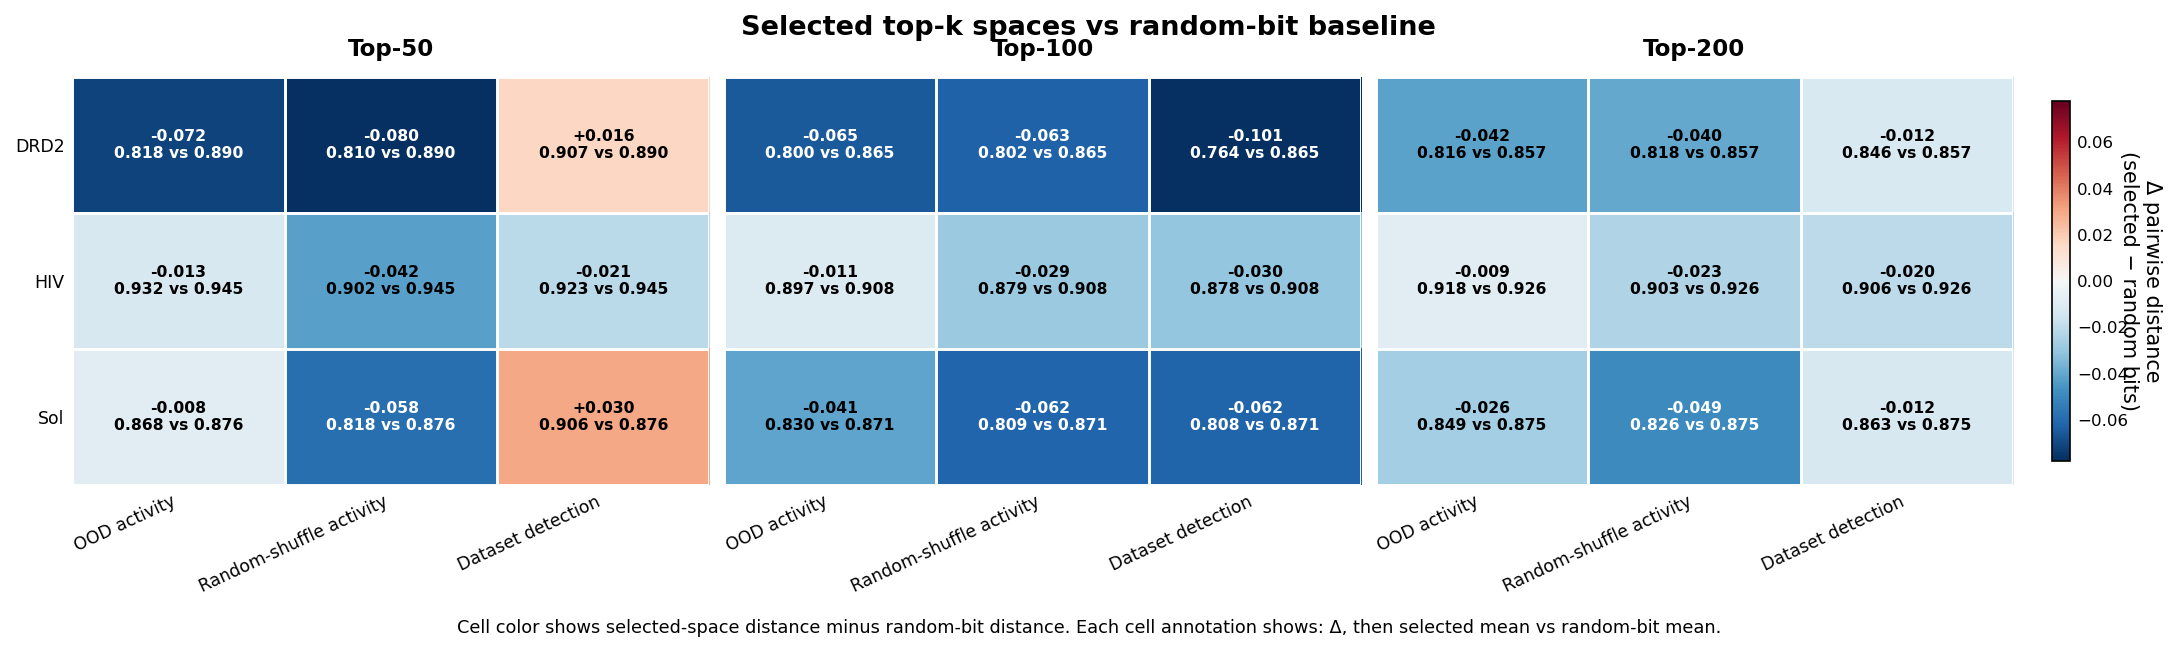

In [ ]:
def fig_selected_vs_random_bits_heatmap(
    dist_all: pd.DataFrame,
    k_values=(50, 100, 200),
):
    set_plot_style()

    selected_sources = [
        ("activity_ood", "OOD activity"),
        ("activity_random_shuffle", "Random-shuffle activity"),
        ("dataset_detection", "Dataset detection"),
    ]

    rows = []

    for k_show in k_values:
        for ds in DATASETS:
            rb = dist_all[
                (dist_all["dataset"] == ds)
                & (dist_all["bit_source"] == "random_bits")
                & (pd.to_numeric(dist_all["k"], errors="coerce") == k_show)
            ]

            if rb.empty:
                continue

            rb_mean = rb["pairwise_distance"].mean()

            for src, src_label in selected_sources:
                sub = dist_all[
                    (dist_all["dataset"] == ds)
                    & (dist_all["bit_source"] == src)
                    & (pd.to_numeric(dist_all["k"], errors="coerce") == k_show)
                ]

                if sub.empty:
                    continue

                selected_mean = sub["pairwise_distance"].mean()
                delta = selected_mean - rb_mean

                rows.append(
                    {
                        "dataset": ds,
                        "dataset_label": DATASET_LABELS.get(ds, ds),
                        "k": k_show,
                        "source": src,
                        "source_label": src_label,
                        "selected_mean": selected_mean,
                        "random_bits_mean": rb_mean,
                        "delta_vs_random": delta,
                    }
                )

    plot_df = pd.DataFrame(rows)

    if len(plot_df) == 0:
        print("No rows available for selected-vs-random heatmap.")
        return

    finite_vals = plot_df["delta_vs_random"].replace([np.inf, -np.inf], np.nan).dropna()

    if len(finite_vals) == 0:
        print("No finite delta values available.")
        return

    vmax = max(np.nanpercentile(np.abs(finite_vals), 95), 0.02)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    cmap = mpl.colormaps["RdBu_r"].copy()
    cmap.set_bad(color="lightgray")

    fig, axes = plt.subplots(
        1,
        len(k_values),
        figsize=(4.8 * len(k_values), 3.8),
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    for ax, k_show in zip(axes[0], k_values):
        sub = plot_df[plot_df["k"] == k_show].copy()

        mat_delta = (
            sub.pivot(
                index="dataset_label",
                columns="source_label",
                values="delta_vs_random",
            )
            .reindex(
                index=[
                    DATASET_LABELS[d]
                    for d in DATASETS
                    if d in plot_df["dataset"].unique()
                ]
            )
            .reindex(
                columns=[
                    "OOD activity",
                    "Random-shuffle activity",
                    "Dataset detection",
                ]
            )
        )

        mat_selected = sub.pivot(
            index="dataset_label",
            columns="source_label",
            values="selected_mean",
        ).reindex(index=mat_delta.index, columns=mat_delta.columns)

        mat_rb = sub.pivot(
            index="dataset_label",
            columns="source_label",
            values="random_bits_mean",
        ).reindex(index=mat_delta.index, columns=mat_delta.columns)

        data = np.ma.masked_invalid(mat_delta.values.astype(float))

        im = ax.imshow(
            data,
            cmap=cmap,
            norm=norm,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_title(f"Top-{k_show}", fontweight="bold", pad=10)
        ax.set_xticks(np.arange(mat_delta.shape[1]))
        ax.set_xticklabels(mat_delta.columns, rotation=25, ha="right")
        ax.set_yticks(np.arange(mat_delta.shape[0]))
        ax.set_yticklabels(mat_delta.index)

        ax.set_xticks(np.arange(-0.5, mat_delta.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, mat_delta.shape[0], 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.4)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.tick_params(axis="both", length=0)

        for spine in ax.spines.values():
            spine.set_visible(False)

        for i in range(mat_delta.shape[0]):
            for j in range(mat_delta.shape[1]):
                delta_val = mat_delta.iloc[i, j]
                selected_val = mat_selected.iloc[i, j]
                rb_val = mat_rb.iloc[i, j]

                if pd.notna(delta_val):
                    text_color = "white" if abs(delta_val) >= 0.55 * vmax else "black"

                    label = f"{delta_val:+.3f}\n" f"{selected_val:.3f} vs {rb_val:.3f}"

                    ax.text(
                        j,
                        i,
                        label,
                        ha="center",
                        va="center",
                        fontsize=7.5,
                        color=text_color,
                        fontweight="bold",
                    )

    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        shrink=0.88,
        pad=0.02,
    )

    cbar.set_label(
        "Δ pairwise distance\n(selected − random bits)",
        rotation=270,
        labelpad=16,
    )

    cbar.ax.tick_params(length=0, labelsize=8)

    fig.suptitle(
        "Selected top-k spaces vs random-bit baseline",
        fontsize=13,
        fontweight="bold",
        y=1.03,
    )

    fig.text(
        0.5,
        -0.03,
        "Cell color shows selected-space distance minus random-bit distance. "
        "Each cell annotation shows: Δ, then selected mean vs random-bit mean.",
        ha="center",
        va="top",
        fontsize=8.5,
    )

    save_fig(fig, "diagnostic_selected_vs_random_bits_heatmap_delta")

    plt.show()
    plt.close(fig)


fig_selected_vs_random_bits_heatmap(dist_all, k_values=(50, 100, 200))

In [13]:
print("Figures saved in:")
print(FIG_ROOT)

figs = sorted(FIG_ROOT.glob("*.png"))

print(f"\nPNG figures: {len(figs)}")
for p in figs:
    print(f"  {p.name}")

Figures saved in:
/home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures/modelwise_tanimoto

PNG figures: 8
  activity_restricted_fold_distance_dt.png
  activity_restricted_fold_distance_lr.png
  activity_restricted_fold_distance_svm.png
  dataset_detection_restricted_fold_distance_grid.png
  diagnostic_distance_heatmap_full_vs_ood_activity_top100.png
  diagnostic_distance_heatmap_full_vs_random_activity_top100.png
  diagnostic_selected_vs_random_bits_heatmap_delta.png
  projection_coverage_full_ecfp4_to_topk_subset.png
